# Deep Q-Learning in un ambiente semplice

Questo notebook mostra un esempio completo di **Deep Q-Learning (DQN)** in un ambiente minimale chiamato **LineWorld**.

L'agente si trova su una linea di 7 posizioni. Parte dalla posizione centrale e può scegliere tra due azioni:

- `0`: muoversi a sinistra;
- `1`: muoversi a destra.

L'episodio termina quando l'agente raggiunge una delle estremità:

- estremità sinistra: ricompensa `-1`;
- estremità destra: ricompensa `+1`.

L'obiettivo è apprendere una policy che conduca l'agente verso destra.

Il notebook implementa i due meccanismi principali introdotti nei DQN:

1. **experience replay**, per riutilizzare le transizioni e ridurne la correlazione;
2. **target network**, per rendere più stabile il target del Q-learning.

## 1. Import delle librerie

Il codice usa PyTorch per definire e addestrare la rete neurale.

In [1]:
# Se PyTorch non è installato, eseguire questa cella una sola volta:
# %pip install torch matplotlib numpy

import random
from collections import deque

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

# Rendiamo l'esperimento riproducibile fissando i seed casuali.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device utilizzato:", device)

Device utilizzato: cuda


## 2. Definizione dell'ambiente LineWorld

Lo stato viene rappresentato con una codifica **one-hot**. Con 7 posizioni, lo stato corrispondente alla posizione 3 è:

$$
[0,0,0,1,0,0,0]
$$

Questa rappresentazione evita di attribuire un significato numerico artificiale alla posizione e rende l'input immediatamente utilizzabile dalla rete.

In [2]:
class LineWorld:
    """Ambiente deterministico con stati disposti lungo una linea."""

    def __init__(self, n_states=7, max_steps=20):
        if n_states < 3:
            raise ValueError("n_states deve essere almeno 3")

        self.n_states = n_states
        self.max_steps = max_steps
        self.start_position = n_states // 2
        self.position = self.start_position
        self.steps = 0

    def _get_state(self):
        # Codifica one-hot dello stato corrente.
        state = np.zeros(self.n_states, dtype=np.float32)
        state[self.position] = 1.0
        return state

    def reset(self):
        """Riporta l'agente alla posizione iniziale."""
        self.position = self.start_position
        self.steps = 0
        return self._get_state()

    def step(self, action):
        """
        Esegue un'azione.

        action = 0 -> sinistra
        action = 1 -> destra
        """
        if action not in (0, 1):
            raise ValueError("L'azione deve essere 0 oppure 1")

        self.steps += 1

        if action == 0:
            self.position -= 1
        else:
            self.position += 1

        # Impediamo di uscire dai limiti dell'ambiente.
        self.position = int(np.clip(self.position, 0, self.n_states - 1))

        reward = 0.0
        terminated = False

        if self.position == 0:
            reward = -1.0
            terminated = True
        elif self.position == self.n_states - 1:
            reward = 1.0
            terminated = True

        truncated = self.steps >= self.max_steps
        done = terminated or truncated

        return self._get_state(), reward, done


env = LineWorld(n_states=7)
state = env.reset()
print("Stato iniziale:", state)

Stato iniziale: [0. 0. 0. 1. 0. 0. 0.]


## 3. Replay buffer

Il replay buffer memorizza transizioni nella forma:

$$
(s_t,a_t,r_{t+1},s_{t+1},done)
$$

Durante l'addestramento si estrae un mini-batch casuale dal buffer. In questo modo:

- una transizione può essere riutilizzata più volte;
- i campioni del mini-batch sono meno correlati temporalmente.

In [3]:
class ReplayBuffer:
    def __init__(self, capacity):
        # deque elimina automaticamente le esperienze più vecchie
        # quando viene raggiunta la capacità massima.
        self.buffer = deque(maxlen=capacity)

    def add(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        return (
            np.array(states, dtype=np.float32),
            np.array(actions, dtype=np.int64),
            np.array(rewards, dtype=np.float32),
            np.array(next_states, dtype=np.float32),
            np.array(dones, dtype=np.float32),
        )

    def __len__(self):
        return len(self.buffer)

## 4. Rete Q

La rete riceve lo stato e restituisce un valore per ciascuna azione:

$$
Q(s,\text{sinistra}),\quad Q(s,\text{destra})
$$

Non è necessario passare l'azione in input: un singolo forward pass produce tutti i valori action-value.

In [4]:
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=32):
        super().__init__()

        # La rete è volutamente piccola perché l'ambiente è molto semplice.
        self.network = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
        )

    def forward(self, x):
        return self.network(x)

## 5. Iperparametri e inizializzazione

Vengono create due reti:

- `policy_net`: viene aggiornata tramite gradient descent;
- `target_net`: viene usata per calcolare target più stabili.

Periodicamente i pesi della policy network vengono copiati nella target network.

In [5]:
state_dim = env.n_states
action_dim = 2

gamma = 0.95
learning_rate = 1e-3
batch_size = 32
buffer_capacity = 2_000
target_update_frequency = 20
num_episodes = 400

# Parametri della strategia epsilon-greedy.
epsilon_start = 1.0
epsilon_end = 0.05
epsilon_decay = 0.985

policy_net = QNetwork(state_dim, action_dim).to(device)
target_net = QNetwork(state_dim, action_dim).to(device)

# All'inizio le due reti devono avere gli stessi parametri.
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=learning_rate)
loss_function = nn.SmoothL1Loss()  # Huber loss, spesso più stabile della MSE
replay_buffer = ReplayBuffer(buffer_capacity)

## 6. Scelta dell'azione con policy epsilon-greedy

Con probabilità $\varepsilon$ viene scelta un'azione casuale; altrimenti si seleziona l'azione con Q-value maggiore.

All'inizio $\varepsilon$ è elevato per favorire l'esplorazione. Successivamente viene ridotto.

In [6]:
def select_action(state, epsilon):
    # Esplorazione: proviamo una delle due azioni casualmente.
    if random.random() < epsilon:
        return random.randrange(action_dim)

    # Exploitation: scegliamo l'azione con Q-value stimato più alto.
    state_tensor = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)

    with torch.no_grad():
        q_values = policy_net(state_tensor)

    return int(q_values.argmax(dim=1).item())

## 7. Aggiornamento DQN

Per ogni transizione del mini-batch, il target è:

$$
y_t=r_{t+1}+\gamma(1-done)\max_{a'}Q_{target}(s_{t+1},a')
$$

Il termine $(1-done)$ annulla il valore futuro quando lo stato successivo è terminale.

La rete viene addestrata riducendo la distanza tra:

$$
Q_{policy}(s_t,a_t)
$$

e il target $y_t$.

In [7]:
def optimize_model():
    # Attendiamo di avere abbastanza campioni per formare un mini-batch.
    if len(replay_buffer) < batch_size:
        return None

    states, actions, rewards, next_states, dones = replay_buffer.sample(batch_size)

    states = torch.tensor(states, dtype=torch.float32, device=device)
    actions = torch.tensor(actions, dtype=torch.int64, device=device).unsqueeze(1)
    rewards = torch.tensor(rewards, dtype=torch.float32, device=device).unsqueeze(1)
    next_states = torch.tensor(next_states, dtype=torch.float32, device=device)
    dones = torch.tensor(dones, dtype=torch.float32, device=device).unsqueeze(1)

    # La rete produce un Q-value per ogni azione.
    # gather seleziona il valore relativo all'azione realmente eseguita.
    current_q_values = policy_net(states).gather(1, actions)

    with torch.no_grad():
        # Il target viene calcolato con la target network.
        max_next_q_values = target_net(next_states).max(dim=1, keepdim=True).values
        target_q_values = rewards + gamma * (1.0 - dones) * max_next_q_values

    loss = loss_function(current_q_values, target_q_values)

    optimizer.zero_grad()
    loss.backward()

    # Il gradient clipping limita aggiornamenti eccessivamente grandi.
    torch.nn.utils.clip_grad_norm_(policy_net.parameters(), max_norm=1.0)
    optimizer.step()

    return float(loss.item())

## 8. Ciclo di addestramento

Per ogni episodio:

1. si ripristina l'ambiente;
2. si sceglie un'azione con la policy epsilon-greedy;
3. si memorizza la transizione nel replay buffer;
4. si esegue un aggiornamento della policy network;
5. periodicamente si aggiorna la target network.

In [8]:
episode_rewards = []
episode_losses = []
epsilon_history = []

epsilon = epsilon_start

for episode in range(1, num_episodes + 1):
    state = env.reset()
    total_reward = 0.0
    losses = []

    done = False
    while not done:
        action = select_action(state, epsilon)
        next_state, reward, done = env.step(action)

        # La nuova esperienza viene aggiunta al dataset utilizzato dal DQN.
        replay_buffer.add(state, action, reward, next_state, done)

        loss = optimize_model()
        if loss is not None:
            losses.append(loss)

        state = next_state
        total_reward += reward

    # Riduzione graduale dell'esplorazione.
    epsilon = max(epsilon_end, epsilon * epsilon_decay)

    # Aggiornamento hard della target network ogni N episodi.
    if episode % target_update_frequency == 0:
        target_net.load_state_dict(policy_net.state_dict())

    episode_rewards.append(total_reward)
    episode_losses.append(np.mean(losses) if losses else np.nan)
    epsilon_history.append(epsilon)

    if episode % 50 == 0:
        recent_mean_reward = np.mean(episode_rewards[-50:])
        print(
            f"Episodio {episode:3d} | "
            f"reward medio ultimi 50: {recent_mean_reward:.3f} | "
            f"epsilon: {epsilon:.3f}"
        )

Episodio  50 | reward medio ultimi 50: 0.660 | epsilon: 0.470
Episodio 100 | reward medio ultimi 50: 0.900 | epsilon: 0.221
Episodio 150 | reward medio ultimi 50: 1.000 | epsilon: 0.104
Episodio 200 | reward medio ultimi 50: 1.000 | epsilon: 0.050
Episodio 250 | reward medio ultimi 50: 1.000 | epsilon: 0.050
Episodio 300 | reward medio ultimi 50: 1.000 | epsilon: 0.050
Episodio 350 | reward medio ultimi 50: 1.000 | epsilon: 0.050
Episodio 400 | reward medio ultimi 50: 1.000 | epsilon: 0.050


## 9. Analisi dell'apprendimento

La media mobile della ricompensa permette di verificare se l'agente impara progressivamente a raggiungere l'estremità destra.

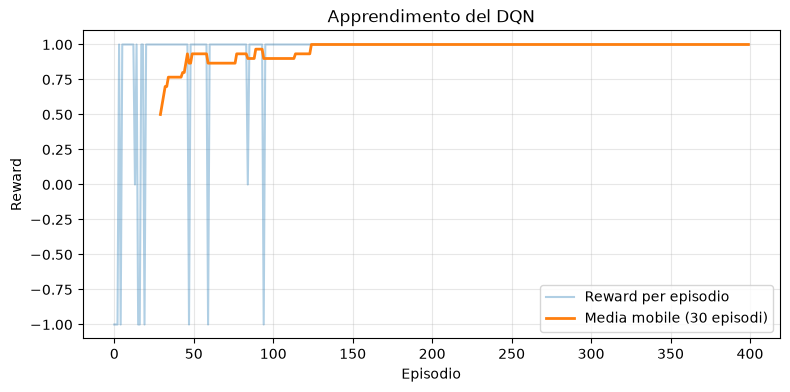

In [9]:
def moving_average(values, window=30):
    values = np.asarray(values, dtype=np.float32)
    if len(values) < window:
        return values
    return np.convolve(values, np.ones(window) / window, mode="valid")

reward_ma = moving_average(episode_rewards, window=30)

plt.figure(figsize=(9, 4))
plt.plot(episode_rewards, alpha=0.35, label="Reward per episodio")
plt.plot(
    np.arange(len(reward_ma)) + 29,
    reward_ma,
    linewidth=2,
    label="Media mobile (30 episodi)",
)
plt.xlabel("Episodio")
plt.ylabel("Reward")
plt.title("Apprendimento del DQN")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 10. Policy appresa

Valutiamo la rete in ciascuno stato non terminale e osserviamo quale azione ha il Q-value maggiore.

In [10]:
action_names = {0: "sinistra", 1: "destra"}

print("Policy greedy appresa:\n")

for position in range(1, env.n_states - 1):
    state = np.zeros(env.n_states, dtype=np.float32)
    state[position] = 1.0

    state_tensor = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)

    with torch.no_grad():
        q_values = policy_net(state_tensor).squeeze(0).cpu().numpy()

    best_action = int(np.argmax(q_values))

    print(
        f"Stato {position}: "
        f"Q(sinistra)={q_values[0]: .3f}, "
        f"Q(destra)={q_values[1]: .3f} -> "
        f"{action_names[best_action]}"
    )

Policy greedy appresa:

Stato 1: Q(sinistra)=-1.000, Q(destra)= 0.818 -> destra
Stato 2: Q(sinistra)= 0.777, Q(destra)= 0.863 -> destra
Stato 3: Q(sinistra)= 0.819, Q(destra)= 0.899 -> destra
Stato 4: Q(sinistra)= 0.864, Q(destra)= 0.944 -> destra
Stato 5: Q(sinistra)= 0.899, Q(destra)= 0.999 -> destra


## 11. Test senza esplorazione

Durante il test poniamo $\varepsilon=0$, quindi l'agente segue sempre la policy greedy appresa.

In [11]:
def run_greedy_episode(verbose=True):
    state = env.reset()
    done = False
    total_reward = 0.0
    visited_positions = [env.position]

    while not done:
        action = select_action(state, epsilon=0.0)
        state, reward, done = env.step(action)
        total_reward += reward
        visited_positions.append(env.position)

    if verbose:
        print("Posizioni visitate:", visited_positions)
        print("Reward totale:", total_reward)

    return total_reward, visited_positions


run_greedy_episode()

Posizioni visitate: [3, 4, 5, 6]
Reward totale: 1.0


(1.0, [3, 4, 5, 6])